# Números-Índices e Estatística Econômica

Este módulo aplica estatística a um problema muito concreto: como comparar valores
econômicos (preços, salários, produção) **ao longo do tempo**, quando o próprio valor do
dinheiro muda? A resposta passa por números-índices — e pela primeira vez no curso, os
dados não são mais só exemplos ilustrativos: vêm **ao vivo da API do Banco Central**.

Pré-requisito: [Módulo 05 — Correlação e Regressão Linear](../05_Correlação_e_Regressão_Linear)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bcb import sgs  # python-bcb: acesso à API do SGS (Banco Central do Brasil)

plt.rcParams.update({'font.size': 12})

## 1. Número-índice simples

Um número-índice relativiza uma série de valores a um **período-base** (que recebe o
valor 100):

$$I_t = \frac{V_t}{V_0} \times 100$$

### Exemplo — preço médio de imóveis

A série abaixo mostra o preço médio de imóveis em um mercado, ao longo de 5 anos.

In [2]:
anos = [2015, 2016, 2017, 2018, 2019]
precos = pd.Series([86095, 96337, 121137, 140687, 161940], index=anos, name='preco')

indice_base_2015 = precos / precos[2015] * 100
indice_base_2018 = precos / precos[2018] * 100

pd.DataFrame({'preço': precos, 'índice (2015=100)': indice_base_2015.round(2),
              'índice (2018=100)': indice_base_2018.round(2)})

,preço,índice (2015=100),índice (2018=100)
2015,86095,100.00,61.20
2016,96337,111.90,68.48
2017,121137,140.70,86.10
2018,140687,163.41,100.00
2019,161940,188.09,115.11


Repare que a **razão** entre dois pontos quaisquer da série não muda, não importa qual
ano vira a base (100):

In [3]:
razao_2015 = indice_base_2015[2019] / indice_base_2015[2015]
razao_2018 = indice_base_2018[2019] / indice_base_2018[2015]
print(f"Razão 2019/2015 com base em 2015: {razao_2015:.4f}")
print(f"Razão 2019/2015 com base em 2018: {razao_2018:.4f}")
print("A escolha do ano-base é só uma questão de referência — a variação real é a mesma.")

Razão 2019/2015 com base em 2015: 1.8809
Razão 2019/2015 com base em 2018: 1.8809
A escolha do ano-base é só uma questão de referência — a variação real é a mesma.


## 2. Índices agregados: Laspeyres e Paasche

Quando o interesse é o preço de uma **cesta de bens** (não um único produto), é preciso
ponderar cada item pela sua importância relativa — sua quantidade consumida. Os dois
índices clássicos diferem em **qual período usam para pesar** a cesta:

$$L = \frac{\sum p_1 q_0}{\sum p_0 q_0} \quad\text{(pesos do período-base)} \qquad\qquad
P = \frac{\sum p_1 q_1}{\sum p_0 q_1} \quad\text{(pesos do período atual)}$$

O **índice de Fisher** (média geométrica dos dois) e o **Marshall-Edgeworth** (que usa a
média das quantidades dos dois períodos) tentam corrigir o viés de cada um isoladamente:
Laspeyres tende a superestimar a inflação (não captura substituição de itens que ficaram
caros), Paasche tende a subestimar.

### Exemplo — cesta de metais usados como matéria-prima

Uma joalheria acompanha o custo de sua cesta de metais nobres entre dois anos:

In [4]:
cesta = pd.DataFrame({
    'p0': [520, 780, 1250],   # preço no ano-base
    'q0': [846, 991, 1275],   # quantidade no ano-base
    'p1': [523, 789, 1254],   # preço no ano atual
    'q1': [896, 1078, 1280],  # quantidade no ano atual
}, index=['prata', 'ouro', 'platina'])

cesta

,p0,q0,p1,q1
prata,520,846,523,896
ouro,780,991,789,1078
platina,1250,1275,1254,1280


In [5]:
soma_p0q0 = (cesta['p0'] * cesta['q0']).sum()
soma_p1q0 = (cesta['p1'] * cesta['q0']).sum()
soma_p0q1 = (cesta['p0'] * cesta['q1']).sum()
soma_p1q1 = (cesta['p1'] * cesta['q1']).sum()

laspeyres = soma_p1q0 / soma_p0q0
paasche = soma_p1q1 / soma_p0q1
fisher = np.sqrt(laspeyres * paasche)

soma_p0_qmedia = (cesta['p0'] * (cesta['q0'] + cesta['q1'])).sum()
soma_p1_qmedia = (cesta['p1'] * (cesta['q0'] + cesta['q1'])).sum()
marshall_edgeworth = soma_p1_qmedia / soma_p0_qmedia

# Índices de quantidade (mesma lógica, invertendo o papel de preço e quantidade)
laspeyres_qtd = soma_p0q1 / soma_p0q0
paasche_qtd = soma_p1q1 / soma_p1q0

# Índice de valor: quanto o gasto total mudou (efeito preço + efeito quantidade)
indice_valor = soma_p1q1 / soma_p0q0

print(f"Laspeyres (preço)        L  = {laspeyres:.4f}  (+{(laspeyres-1):.2%})")
print(f"Paasche (preço)          P  = {paasche:.4f}  (+{(paasche-1):.2%})")
print(f"Fisher                       = {fisher:.4f}")
print(f"Marshall-Edgeworth            = {marshall_edgeworth:.4f}")
print(f"Laspeyres (quantidade)   Lq = {laspeyres_qtd:.4f}  (+{(laspeyres_qtd-1):.2%})")
print(f"Paasche (quantidade)     Pq = {paasche_qtd:.4f}  (+{(paasche_qtd-1):.2%})")
print(f"Índice de valor              = {indice_valor:.4f}  (+{(indice_valor-1):.2%})")

Laspeyres (preço)        L  = 1.0059  (+0.59%)
Paasche (preço)          P  = 1.0060  (+0.60%)
Fisher                       = 1.0060
Marshall-Edgeworth            = 1.0060
Laspeyres (quantidade)   Lq = 1.0357  (+3.57%)
Paasche (quantidade)     Pq = 1.0358  (+3.58%)
Índice de valor              = 1.0419  (+4.19%)


Os preços da cesta subiram pouco (~0,6%), mas as quantidades consumidas subiram bem
mais (~3,6%) — o índice de valor (~4,2%) combina os dois efeitos.

## 3. Índices de preços reais do Brasil — direto da API do Banco Central

O Brasil tem três índices de preços amplamente usados: **IPCA** (referência oficial de
inflação, usada para meta do Banco Central), **INPC** (mais focado em famílias de renda
mais baixa) e **IGP-M** (calculado pela FGV, usado em muitos contratos de aluguel). Em vez
de digitar números, buscamos as séries reais direto do **SGS — Sistema Gerenciador de
Séries Temporais do Banco Central** (a mesma fonte de dados oficiais que orienta política
monetária no país).

In [6]:
codigos_sgs = {'ipca': 433, 'inpc': 188, 'igpm': 189}

precos_br = sgs.get(codigos_sgs, start='2015-01-01')
print(f"{len(precos_br)} observações mensais, de {precos_br.index.min():%Y-%m} a {precos_br.index.max():%Y-%m}")
precos_br.tail(6)

139 observações mensais, de 2015-01 a 2026-07


,ipca,inpc,igpm
Date,,,
2026-02-01,0.70,0.56,-0.73
2026-03-01,0.88,0.91,0.52
2026-04-01,0.67,0.81,2.73
2026-05-01,0.58,0.65,0.84
2026-06-01,0.16,0.14,-0.50
2026-07-01,NaN,NaN,-1.16


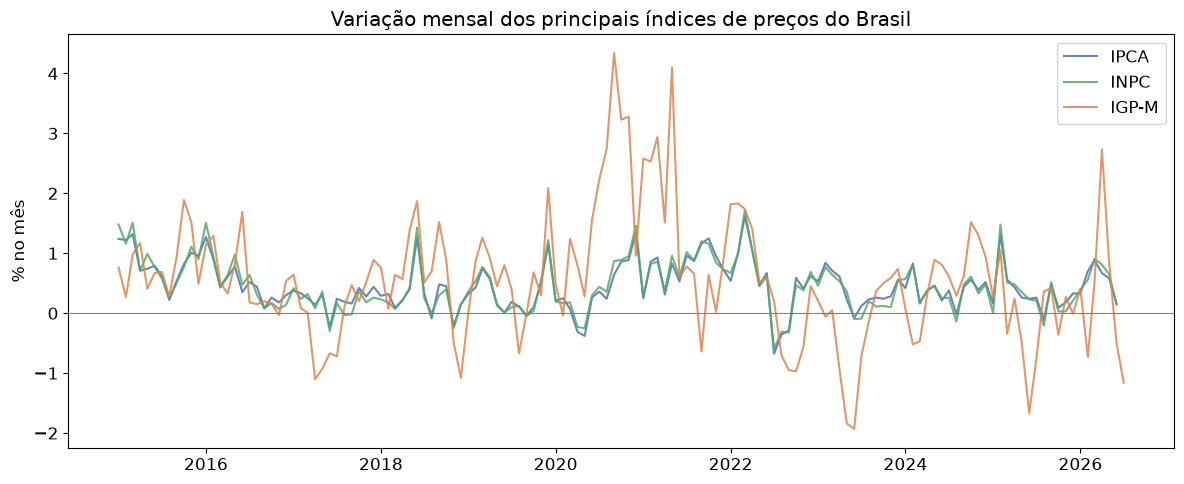

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for coluna, rotulo, cor in zip(['ipca', 'inpc', 'igpm'],
                                 ['IPCA', 'INPC', 'IGP-M'],
                                 ['#4C72B0', '#55A868', '#DD8452']):
    ax.plot(precos_br.index, precos_br[coluna], label=rotulo, color=cor, alpha=0.85)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Variação mensal dos principais índices de preços do Brasil')
ax.set_ylabel('% no mês')
ax.legend()
plt.tight_layout()
plt.savefig('img_indices_precos_brasil.png', dpi=110)
plt.show()

### IPCA acumulado em 12 meses

Como o IPCA vem em variação **mensal**, a inflação "acumulada em 12 meses" (o número
comentado no noticiário) é o produto composto das últimas 12 variações — exatamente a
mesma lógica de encadeamento de números-índices do início deste notebook, aplicada mês a
mês:

$$\text{IPCA}_{12m} = \left[\prod_{i=0}^{11}\left(1+\frac{\text{IPCA}_{t-i}}{100}\right) - 1\right] \times 100$$

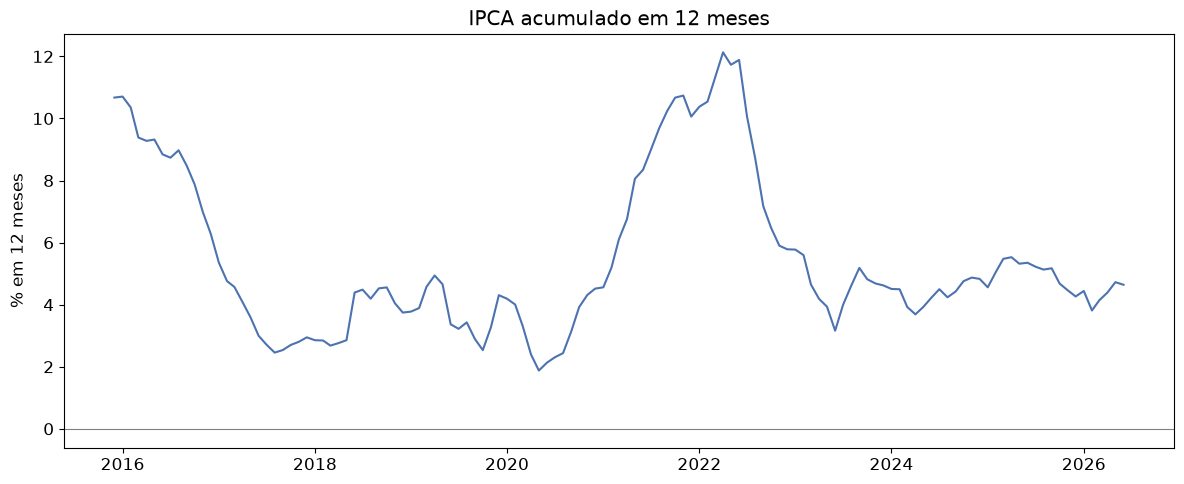

IPCA acumulado nos últimos 12 meses disponíveis: 4.64%


In [8]:
ipca_mensal = precos_br['ipca'].dropna() / 100
ipca_12m = (1 + ipca_mensal).rolling(window=12).apply(np.prod, raw=True).sub(1).mul(100)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ipca_12m.index, ipca_12m, color='#4C72B0')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('IPCA acumulado em 12 meses')
ax.set_ylabel('% em 12 meses')
plt.tight_layout()
plt.savefig('img_ipca_acumulado_12m.png', dpi=110)
plt.show()

print(f"IPCA acumulado nos últimos 12 meses disponíveis: {ipca_12m.dropna().iloc[-1]:.2f}%")

## 4. Deflacionamento

Um valor **nominal** está expresso nos preços da época em que foi medido; um valor
**real** foi ajustado para remover o efeito da inflação, permitindo comparação justa entre
períodos diferentes:

$$\text{Valor real}_t = \text{Valor nominal}_t \times \frac{\text{Índice de preços}_{\text{base}}}{\text{Índice de preços}_t}$$

### Exemplo — quanto vale hoje um valor de anos atrás

Usando o IPCA real buscado acima, construímos um índice de preços acumulado (base 100 no
primeiro mês da série) e convertemos um valor nominal do passado para poder de compra de
hoje.

In [9]:
def fmt_brl(valor):
    """Formata número no padrão brasileiro: ponto como milhar, vírgula como decimal."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Índice de preços acumulado, encadeando as variações mensais (base 100 no primeiro mês)
indice_ipca = (1 + ipca_mensal).cumprod() * 100
indice_ipca.iloc[0] = 100  # normaliza o primeiro ponto exatamente em 100

data_referencia = indice_ipca.index[0]
data_atual = indice_ipca.index[-1]
valor_nominal_passado = 3000  # em R$, na data_referencia

valor_real_hoje = valor_nominal_passado * (indice_ipca.iloc[-1] / indice_ipca.iloc[0])

print(f"{fmt_brl(valor_nominal_passado)} em {data_referencia:%m/%Y}")
print(f"equivalem, em poder de compra de {data_atual:%m/%Y}, a aproximadamente:")
print(fmt_brl(valor_real_hoje))
print(f"\n(inflação acumulada no período: {(indice_ipca.iloc[-1]/indice_ipca.iloc[0] - 1):.1%})")

R$ 3.000,00 em 01/2015
equivalem, em poder de compra de 06/2026, a aproximadamente:
R$ 5.654,66

(inflação acumulada no período: 88.5%)


## 5. Encadeamento de índices

Séries de preços de longo prazo frequentemente trocam de metodologia ou de cesta de bens
ao longo do tempo (novos produtos substituem antigos, pesos são atualizados). O
**encadeamento** costura índices calculados com bases diferentes numa série contínua,
aplicando a variação percentual de cada trecho sobre o nível acumulado do trecho anterior
— é exatamente o que a fórmula do IPCA acumulado (seção 3) já fez mês a mês, e o que
`indice_ipca.cumprod()` (seção 4) fez para toda a série de uma vez.

## 6. Exercícios de fixação

1. Uma cesta de bens de construção civil tem os seguintes dados entre dois anos:

   | Item | p0 | q0 | p1 | q1 |
   |---|---|---|---|---|
   | cimento | 182 | 11000 | 180 | 18964 |
   | cal | 150 | 10530 | 143 | 12567 |
   | areia | 97 | 985 | 82 | 998 |

   Calcule os índices de Laspeyres e Paasche de preços para essa cesta.
2. Busque a série do IGP-M dos últimos 20 meses via `sgs.get()` e calcule o IGP-M
   acumulado em 12 meses, no mesmo espírito da seção 3.

In [10]:
# 1.
cesta_ex = pd.DataFrame({
    'p0': [182, 150, 97], 'q0': [11000, 10530, 985],
    'p1': [180, 143, 82], 'q1': [18964, 12567, 998],
}, index=['cimento', 'cal', 'areia'])

L_ex = (cesta_ex['p1'] * cesta_ex['q0']).sum() / (cesta_ex['p0'] * cesta_ex['q0']).sum()
P_ex = (cesta_ex['p1'] * cesta_ex['q1']).sum() / (cesta_ex['p0'] * cesta_ex['q1']).sum()
print(f"1) Laspeyres = {L_ex:.4f}   Paasche = {P_ex:.4f}")

# 2.
igpm_20m = sgs.get({'igpm': 189}, last=20)
igpm_mensal = igpm_20m['igpm'].dropna() / 100
igpm_12m = (1 + igpm_mensal).rolling(window=12).apply(np.prod, raw=True).sub(1).mul(100)
print(f"2) IGP-M acumulado nos últimos 12 meses disponíveis: {igpm_12m.dropna().iloc[-1]:.2f}%")

1) Laspeyres = 0.9700   Paasche = 0.9741
2) IGP-M acumulado nos últimos 12 meses disponíveis: 2.77%


## Encerramento do módulo

Este foi o primeiro módulo a buscar dados reais e atuais direto de uma API pública — o
mesmo padrão de acesso ao SGS do Banco Central será reaproveitado nos módulos de
[Econometria](../07_Econometria_I) e, principalmente, em
[Séries Temporais](../09_Séries_Temporais).

## Bibliografia
- TRIOLA, Mario F. *Introdução à Estatística*. 8. ed. Rio de Janeiro: LTC, 2005.
- BUSSAB, Wilton O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- IBGE. *Sistema Nacional de Índices de Preços ao Consumidor: métodos de cálculo*. Rio de Janeiro: IBGE, 2013.
- Banco Central do Brasil. *Sistema Gerenciador de Séries Temporais (SGS)*. Disponível em: <https://www3.bcb.gov.br/sgspub/>.